In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [2]:
df= pd.read_csv("books.csv")

In [4]:
df.head()

,Unnamed: 0,book_id,authors,original_publication_year,title,language_code,average_rating,image_url,description
0,0,2767052,Suzanne Collins,2008.0,"The Hunger Games (The Hunger Games, #1)",eng,4.34,https://images.gr-assets.com/books/1447303603m...,First in the ground-breaking HUNGER GAMES tril...
1,1,3,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,https://images.gr-assets.com/books/1474154022m...,Rescued from the outrageous neglect of his aun...
2,2,41865,Stephenie Meyer,2005.0,"Twilight (Twilight, #1)",en-US,3.57,https://images.gr-assets.com/books/1361039443m...,"When 17 year old Isabella Swan moves to Forks,..."
3,3,2657,Harper Lee,1960.0,To Kill a Mockingbird,eng,4.25,https://images.gr-assets.com/books/1361975680m...,Harper Lee's classic novel of a lawyer in the ...
4,4,4671,F. Scott Fitzgerald,1925.0,The Great Gatsby,eng,3.89,https://images.gr-assets.com/books/1490528560m...,The only authorized edition of the twentieth-c...


In [5]:
df.shape

(4766, 9)

In [6]:
df.columns

Index(['Unnamed: 0', 'book_id', 'authors', 'original_publication_year',
       'title', 'language_code', 'average_rating', 'image_url', 'description'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4766 entries, 0 to 4765
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 4766 non-null   int64  
 1   book_id                    4766 non-null   int64  
 2   authors                    4766 non-null   object 
 3   original_publication_year  4766 non-null   float64
 4   title                      4766 non-null   object 
 5   language_code              4766 non-null   object 
 6   average_rating             4766 non-null   float64
 7   image_url                  4766 non-null   object 
 8   description                4766 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 335.2+ KB


In [8]:
df.isnull().sum()

Unnamed: 0                   0
book_id                      0
authors                      0
original_publication_year    0
title                        0
language_code                0
average_rating               0
image_url                    0
description                  0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop(columns=['Unnamed: 0'])

df.head()

,book_id,authors,original_publication_year,title,language_code,average_rating,image_url,description
0,2767052,Suzanne Collins,2008.0,"The Hunger Games (The Hunger Games, #1)",eng,4.34,https://images.gr-assets.com/books/1447303603m...,First in the ground-breaking HUNGER GAMES tril...
1,3,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Sorcerer's Stone (Harry P...,eng,4.44,https://images.gr-assets.com/books/1474154022m...,Rescued from the outrageous neglect of his aun...
2,41865,Stephenie Meyer,2005.0,"Twilight (Twilight, #1)",en-US,3.57,https://images.gr-assets.com/books/1361039443m...,"When 17 year old Isabella Swan moves to Forks,..."
3,2657,Harper Lee,1960.0,To Kill a Mockingbird,eng,4.25,https://images.gr-assets.com/books/1361975680m...,Harper Lee's classic novel of a lawyer in the ...
4,4671,F. Scott Fitzgerald,1925.0,The Great Gatsby,eng,3.89,https://images.gr-assets.com/books/1490528560m...,The only authorized edition of the twentieth-c...


In [11]:
df['authors'].value_counts().head(10)

authors
Terry Pratchett        39
Stephen King           38
James Patterson        30
Nora Roberts           29
Agatha Christie        29
J.D. Robb              29
Laurell K. Hamilton    27
Janet Evanovich        27
Michael Connelly       27
Meg Cabot              25
Name: count, dtype: int64

In [12]:
df['average_rating'].describe()

count    4766.000000
mean        4.042776
std         0.233440
min         2.470000
25%         3.900000
50%         4.060000
75%         4.200000
max         4.770000
Name: average_rating, dtype: float64

In [13]:
df['original_publication_year'].describe()

count    4766.000000
mean     1988.510071
std       138.106988
min      -762.000000
25%      1996.000000
50%      2006.000000
75%      2011.000000
max      2017.000000
Name: original_publication_year, dtype: float64

In [14]:
df['description'].str.len().describe()

count    4766.000000
mean      898.481536
std       570.210069
min         6.000000
25%       501.250000
50%       855.500000
75%      1186.000000
max      5809.000000
Name: description, dtype: float64

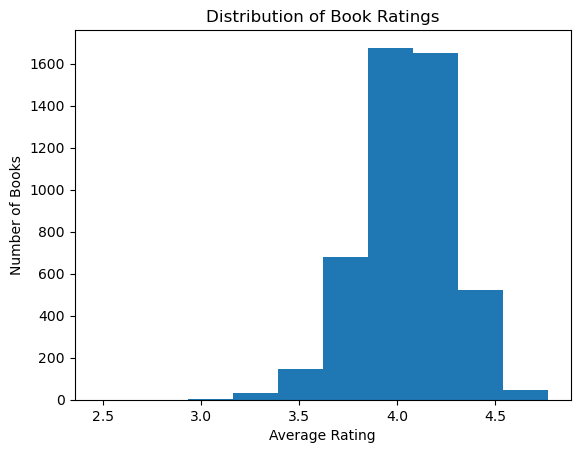

In [15]:
plt.hist(df['average_rating'])
plt.xlabel('Average Rating')
plt.ylabel('Number of Books')
plt.title('Distribution of Book Ratings')
plt.show()

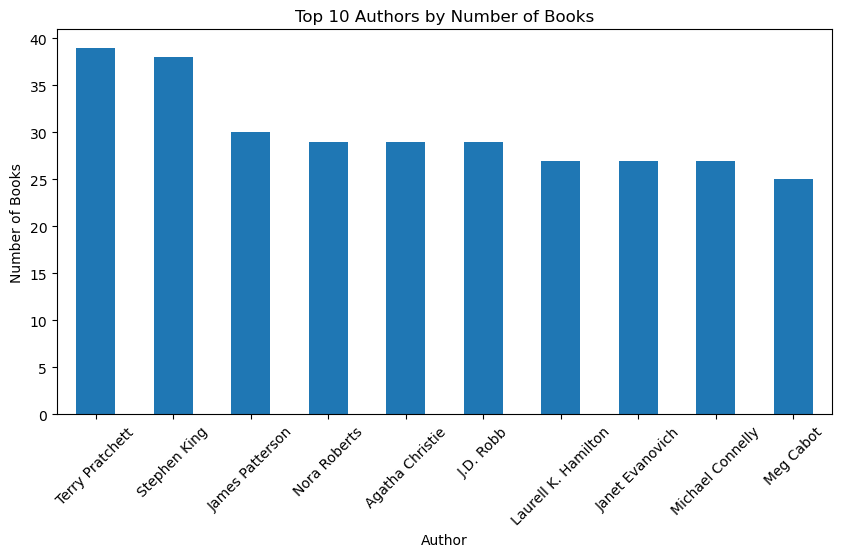

In [34]:
top_authors = df['authors'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_authors.plot(kind='bar')
plt.title('Top 10 Authors by Number of Books')
plt.xlabel('Author')
plt.ylabel('Number of Books')
plt.xticks(rotation=45)
plt.show()

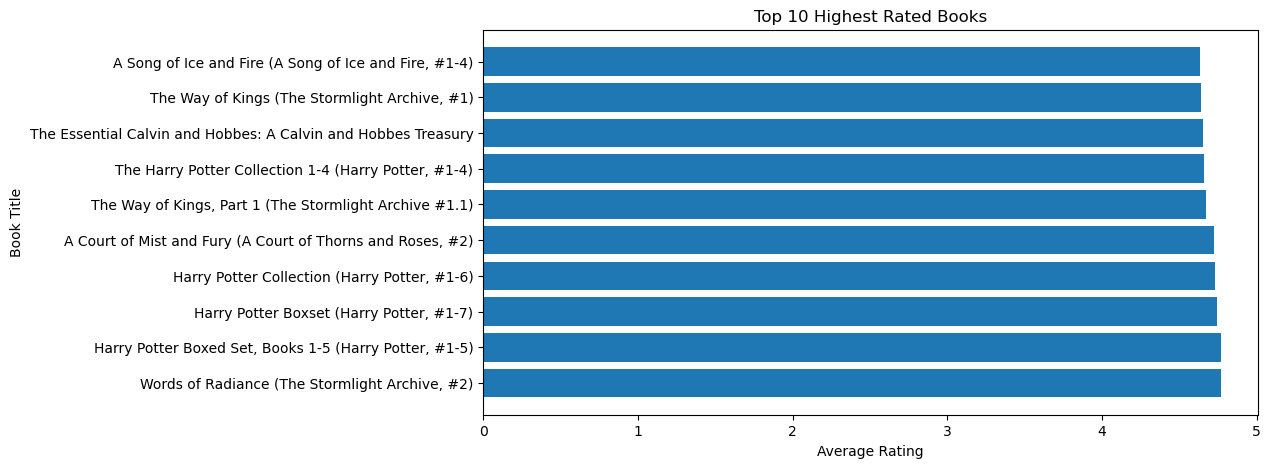

In [35]:
top_books = df.sort_values(
    by='average_rating',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
plt.barh(top_books['title'], top_books['average_rating'])
plt.title('Top 10 Highest Rated Books')
plt.xlabel('Average Rating')
plt.ylabel('Book Title')
plt.show()

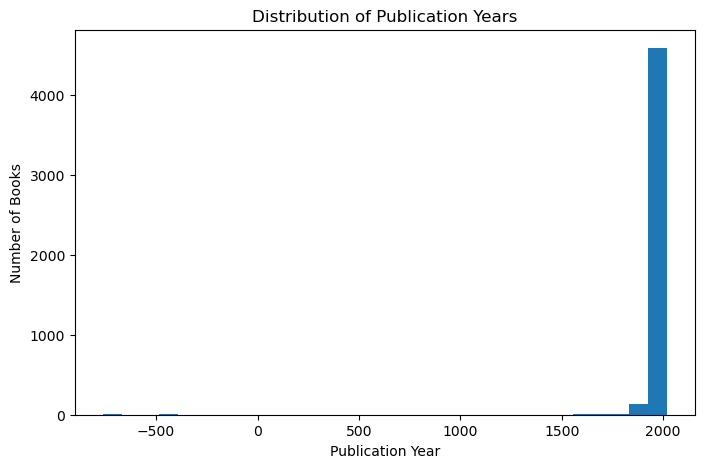

In [36]:
plt.figure(figsize=(8,5))
plt.hist(df['original_publication_year'], bins=30)
plt.title('Distribution of Publication Years')
plt.xlabel('Publication Year')
plt.ylabel('Number of Books')
plt.show()

In [16]:
df['features'] = (
    df['title'] + ' ' +
    df['authors'] + ' ' +
    df['description']
)

In [23]:
df[['title', 'features']].head(2)

,title,features
0,"The Hunger Games (The Hunger Games, #1)","The Hunger Games (The Hunger Games, #1) Suzann..."
1,Harry Potter and the Sorcerer's Stone (Harry P...,Harry Potter and the Sorcerer's Stone (Harry P...


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

tfidf_matrix = tfidf.fit_transform(df['features'])

tfidf_matrix.shape

(4766, 5000)

In [25]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(tfidf_matrix)

similarity.shape

(4766, 4766)

In [26]:
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

indices.head()

title
The Hunger Games (The Hunger Games, #1)                     0
Harry Potter and the Sorcerer's Stone (Harry Potter, #1)    1
Twilight (Twilight, #1)                                     2
To Kill a Mockingbird                                       3
The Great Gatsby                                            4
dtype: int64

In [29]:
def recommend(book_title, n=5):
    
    if book_title not in indices:
        return "Book not found"
    
    idx = indices[book_title]

    sim_scores = list(enumerate(similarity[idx]))

    sim_scores = sorted(
        sim_scores,
        key=lambda x: x[1],
        reverse=True
    )

    sim_scores = sim_scores[1:n+1]

    book_indices = [i[0] for i in sim_scores]

    return df[['title', 'authors', 'average_rating']].iloc[book_indices]

In [28]:
recommend("The Hobbit")

,title,authors,average_rating
985,"The History of the Hobbit, Part One: Mr. Baggins","John D. Rateliff, J.R.R. Tolkien",3.81
846,J.R.R. Tolkien 4-Book Boxed Set: The Hobbit an...,J.R.R. Tolkien,4.59
1867,The Children of Húrin,"J.R.R. Tolkien, Christopher Tolkien, Alan Lee",3.94
141,"The Return of the King (The Lord of the Rings,...",J.R.R. Tolkien,4.51
166,"The Lord of the Rings (The Lord of the Rings, ...",J.R.R. Tolkien,4.47


In [30]:
recommend("abcdefxyud")

'Book not found'

In [31]:
recommend("Harry Potter and the Sorcerer's Stone")

'Book not found'

In [32]:
df[df['title'].str.contains('Harry Potter', case=False, na=False)][['title']]

,title
1,Harry Potter and the Sorcerer's Stone (Harry P...
16,Harry Potter and the Order of the Phoenix (Har...
18,Harry Potter and the Chamber of Secrets (Harry...
19,Harry Potter and the Goblet of Fire (Harry Pot...
20,Harry Potter and the Deathly Hallows (Harry Po...
22,Harry Potter and the Half-Blood Prince (Harry ...
247,Harry Potter and the Cursed Child - Parts One ...
371,"Harry Potter Boxset (Harry Potter, #1-7)"
1686,Harry Potter: Film Wizardry
1744,"The Harry Potter Collection 1-4 (Harry Potter,..."


In [33]:
recommend("Harry Potter and the Sorcerer's Stone (Harry Potter, #1)")

,title,authors,average_rating
371,"Harry Potter Boxset (Harry Potter, #1-7)",J.K. Rowling,4.74
20,Harry Potter and the Deathly Hallows (Harry Po...,"J.K. Rowling, Mary GrandPré",4.61
22,Harry Potter and the Half-Blood Prince (Harry ...,"J.K. Rowling, Mary GrandPré",4.54
1118,Quidditch Through the Ages,"Kennilworthy Whisp, J.K. Rowling",3.85
247,Harry Potter and the Cursed Child - Parts One ...,"John Tiffany, Jack Thorne, J.K. Rowling",3.75


## Conclusion

In this project, a content-based Book Recommendation System was developed using Python, Pandas, and Scikit-learn. The dataset was first cleaned and explored through various visualizations to understand the distribution of ratings, publication years, authors, and highly rated books.

To generate recommendations, book metadata including title, author, and description were combined into a single feature. The textual data was then transformed into numerical vectors using TF-IDF (Term Frequency–Inverse Document Frequency) vectorization. Cosine similarity was used to measure the similarity between books based on their textual features.

The final system successfully recommends books that are similar in content, theme, and author to a user-selected book. For example, books from the same series or books with similar themes were recommended with high similarity scores, demonstrating the effectiveness of content-based filtering.

This project provided practical experience in data preprocessing, exploratory data analysis, natural language processing, feature engineering, and recommendation systems. Future improvements could include incorporating user ratings, genres, collaborative filtering techniques, and deploying the model as a web application using Streamlit or Flask.
